## **2° Module**: TT - Image Preprocessing
* September 23°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Module 2 turns the raw DICOM files into what PyRadiomics needs in Module 3: for every
lesion, an **image crop and a binary mask that are geometrically aligned**, at the
original resolution of the mammogram.

Three decisions already fixed shape this module:

- **No resize to 224×224** (D-009). The most discriminative mass features are size
  measurements, and a common grid would erase them. The crop keeps the native pixels.
- **No CLAHE in the radiomic path** (D-010). CLAHE is a content-dependent local
  equalisation that breaks the reproducibility of first-order and GLCM features under
  IBSI. A CLAHE variant is exported alongside, only to measure its effect in Module 3.
- **Masses and calcifications stay separate** (D-005). They are written to separate
  folders and never mixed.

The module answers four questions before exporting anything:

1. Does every mask have the geometry of its mammogram? (H-004 found 80 that do not.)
2. When it does not, what is the correct way to bring it into the image space, and
   how can that be **verified** rather than assumed?
3. Is each mask a single clean region, as a lesion annotation should be?
4. Do the exported pairs load correctly in PyRadiomics?

#### **1° Setup**

**a.** Import the necessary libraries

In [1]:
import time
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import pydicom
import cv2
import SimpleITK as sitk
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import radiomics
print("Environment:")
print(f"  pydicom     : {pydicom.__version__}")
print(f"  opencv      : {cv2.__version__}")
print(f"  SimpleITK   : {sitk.Version_VersionString()}")
print(f"  pyradiomics : {radiomics.__version__}  (built from commit 8ed5793, see Code/env/README.md)")
print(f"  numpy       : {np.__version__}")

Environment:
  pydicom     : 3.0.2
  opencv      : 4.11.0
  SimpleITK   : 2.5.6
  pyradiomics : 0.1.dev1+g8ed579383  (built from commit 8ed5793, see Code/env/README.md)
  numpy       : 2.2.6


**b.** Configuration

In [2]:
SEED = 42
DATA_DIR = Path("/Users/alexander_san/TT/Data")
OUT_DIR = DATA_DIR / "processed" / "m2"          # not versioned, like the rest of Data/
RESULTS_DIR = Path("/Users/alexander_san/TT/Code/results")
FIG_DIR = Path("/Users/alexander_san/TT/Docs/Figures")

# Crop margin around the lesion bounding box. 20 px is the margin the CBIS-DDSM
# itself uses for its official crops (verified in section 3), so the crops stay
# comparable with the dataset convention.
MARGIN = 20

# CLAHE variant only (D-010): OpenCV defaults, on the full mammogram converted to 8 bits
# (section 5b explains why 8 bits and not 16)
CLAHE_CLIP, CLAHE_TILES = 2.0, (8, 8)

# Geometry of the misaligned masks (section 2)
SCALE_087, SCALE_TOL = 0.870, 0.005

N_WORKERS = 8
for ft in ("mass", "calcification"):
    (OUT_DIR / ft).mkdir(parents=True, exist_ok=True)

**c.** Load the unified index from Module 1

`case_id` is the CBIS-DDSM name of the ROI folder, for example
`Mass-Training_P_00001_LEFT_CC_1`. It is unique per lesion and keeps every output file
traceable to the original dataset.

In [3]:
df = pd.read_csv(DATA_DIR / "cbis_ddsm_unified.csv")
df["finding_type"] = df["abnormality type"]
df["case_id"] = df["folder_roi"]
assert df.case_id.is_unique

print(f"Records: {len(df)}  ·  distinct full mammograms: {df.path_full_mammo.nunique()}")
print(f"Mammograms shared by more than one lesion: {df.path_full_mammo.duplicated(keep=False).sum()} records")
print()
print(pd.crosstab([df.finding_type, df.split], df.label.map({0: "benign", 1: "malignant"}), margins=True))

Records: 3568  ·  distinct full mammograms: 3103
Mammograms shared by more than one lesion: 758 records

label                benign  malignant   All
finding_type  split                         
calcification test      197        129   326
              train    1002        544  1546
mass          test      231        147   378
              train     681        637  1318
All                    2111       1457  3568


#### **2° Geometry audit**

**a.** Image against mask, all records

For each record the mammogram header gives its size, and the mask is read in full to
check its values and count its connected components. Section 4 comes back to the
components.

In [4]:
def audit_record(i):
    row = df.loc[i]
    hdr = pydicom.dcmread(row.path_full_mammo, stop_before_pixels=True)
    m = pydicom.dcmread(row.path_roi_mask).pixel_array
    n, _, st, _ = cv2.connectedComponentsWithStats((m > 0).astype(np.uint8), connectivity=8)
    areas = np.sort(st[1:, cv2.CC_STAT_AREA])[::-1]
    return dict(i=i, img_rows=int(hdr.Rows), img_cols=int(hdr.Columns),
                mask_rows=m.shape[0], mask_cols=m.shape[1],
                mask_values=",".join(map(str, np.unique(m).tolist())),
                mask_area_raw=int((m > 0).sum()), n_components=n - 1,
                largest_component=int(areas[0]) if len(areas) else 0,
                second_component=int(areas[1]) if len(areas) > 1 else 0)


t0 = time.time()
with ThreadPoolExecutor(N_WORKERS) as ex:
    audit = pd.DataFrame(list(ex.map(audit_record, df.index))).set_index("i")
df = df.join(audit)

ratio_r, ratio_c = df.mask_rows / df.img_rows, df.mask_cols / df.img_cols
same = (df.mask_rows == df.img_rows) & (df.mask_cols == df.img_cols)
scaled = ((ratio_r - SCALE_087).abs() < SCALE_TOL) & ((ratio_c - SCALE_087).abs() < SCALE_TOL)
df["mismatch"] = np.select([same, scaled], ["none", "scaled"], default="offset")

print(f"Audited {len(df)} records in {time.time() - t0:.0f} s")
print(f"Mask values        : {df.mask_values.value_counts().to_dict()}")
print(f"Empty masks        : {(df.mask_area_raw == 0).sum()}")
print()
print(pd.crosstab(df.mismatch, df.finding_type, margins=True))
print()
mis = df[df.mismatch != "none"]
print("Mask / image size ratio among mismatched records:")
print(pd.DataFrame({"rows": ratio_r[mis.index], "cols": ratio_c[mis.index], "kind": mis.mismatch})
      .groupby("kind").describe().T.round(4).to_string())

Audited 3568 records in 160 s
Mask values        : {'0,255': 3568}
Empty masks        : 0

finding_type  calcification  mass   All
mismatch                               
none                   1870  1618  3488
offset                    2     0     2
scaled                    0    78    78
All                    1872  1696  3568

Mask / image size ratio among mismatched records:
kind        offset   scaled
rows count  2.0000  78.0000
     mean   1.0052   0.8701
     std    0.0122   0.0000
     min    0.9966   0.8700
     25%    1.0009   0.8700
     50%    1.0052   0.8701
     75%    1.0095   0.8701
     max    1.0138   0.8702
cols count  2.0000  78.0000
     mean   1.0065   0.8702
     std    0.0056   0.0001
     min    1.0026   0.8700
     25%    1.0046   0.8701
     50%    1.0065   0.8702
     75%    1.0085   0.8702
     max    1.0105   0.8704


**b.** Two different kinds of mismatch

The 80 mismatched records of H-004 are not one problem but two:

- **`scaled`** (78 masses): the mask is the image shrunk by a factor of $0.870$ in
  **both** axes. A uniform factor means the same field of view sampled on a coarser grid,
  so the fix is to resample the mask up to the image grid.
- **`offset`** (2 calcifications of `P_00353`): the sizes differ by a few tens of pixels
  and not in proportion. That is not a change of scale.

Treating both the same way, as H-004 proposed, would misplace the second kind. The next
section establishes which alignment is correct for each and verifies it.

> The factor $0.870$ coincides with $43.5/50$, the ratio between two sampling pitches
> (µm per pixel) among the digitisers used for the DDSM. That would explain why some masks
> live on a different grid. **Hypothesis to verify against the DDSM documentation before
> citing it.**

#### **3° Aligning and verifying the masks**

**a.** The alignment rule

- `none`: the mask is used as is.
- `scaled`: resampled to the image size with **nearest-neighbour** interpolation, which
  keeps the mask binary. `INTER_NEAREST_EXACT` is used rather than `INTER_NEAREST`,
  which in OpenCV carries a half-pixel shift.
- `offset`: no scaling; the mask is anchored at the top-left corner and padded or cut
  to the image size.

In [5]:
def align_mask(mask, shape, kind):
    H, W = shape
    if kind == "none":
        return mask
    if kind == "scaled":
        return cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST_EXACT)
    out = np.zeros((H, W), mask.dtype)          # "offset": same scale, top-left anchor
    h, w = min(H, mask.shape[0]), min(W, mask.shape[1])
    out[:h, :w] = mask[:h, :w]
    return out


def bbox(mask):
    ys, xs = np.nonzero(mask)
    return ys.min(), ys.max() + 1, xs.min(), xs.max() + 1

**b.** An independent reference: the official crops

The CBIS-DDSM ships, for most lesions, a third file: a crop of the lesion cut by the
dataset authors. It can be located inside the mammogram by template matching, which
gives an **independent** record of where the lesion is.

Two facts about those crops matter, and both are checked below:

1. Their intensities are **rescaled**: the crop equals the mammogram multiplied by a
   per-case gain, so they are located with normalised cross-correlation (invariant to
   a linear change of intensity) rather than by pixel difference. It is also the reason
   the official crops are **not** used for feature extraction: first-order features
   would inherit an arbitrary gain.
2. When image and mask agree, the crop is exactly the mask bounding box plus **20 px**
   on every side. That relation is the verification test: if an aligned mask satisfies
   it, the alignment is correct to the pixel.

The test runs on every record that has an official crop.

In [6]:
def locate(img, crop, scale=0.25, pad=48):
    # Coarse search on downsampled images, then exact search in a small full-res window
    f = lambda z: cv2.resize(z.astype(np.float32), None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    _, _, _, (x, y) = cv2.minMaxLoc(cv2.matchTemplate(f(img), f(crop), cv2.TM_CCOEFF_NORMED))
    y, x = int(y / scale), int(x / scale)
    Y0, X0 = max(0, y - pad), max(0, x - pad)
    win = img[Y0:y + crop.shape[0] + pad, X0:x + crop.shape[1] + pad].astype(np.float32)
    _, ncc, _, (bx, by) = cv2.minMaxLoc(cv2.matchTemplate(win, crop.astype(np.float32), cv2.TM_CCOEFF_NORMED))
    return Y0 + by, X0 + bx, ncc


def margins(crop_pos, crop_shape, mask):
    # Official crop box minus mask bounding box, per side: (-20, -20, 20, 20) when aligned
    cy, cx = crop_pos
    y0, y1, x0, x1 = bbox(mask)
    return cy - y0, cx - x0, cy + crop_shape[0] - y1, cx + crop_shape[1] - x1


ALT = {"scaled": "offset", "offset": "scaled"}


def verify_record(i):
    row = df.loc[i]
    img = pydicom.dcmread(row.path_full_mammo).pixel_array
    raw = (pydicom.dcmread(row.path_roi_mask).pixel_array > 0).astype(np.uint8)
    crop = pydicom.dcmread(row.path_cropped).pixel_array
    cy, cx, ncc = locate(img, crop)
    sub = img[cy:cy + crop.shape[0], cx:cx + crop.shape[1]].astype(np.float64).ravel()
    gain = float(np.dot(sub, crop.ravel()) / np.dot(sub, sub))
    rec = dict(i=i, ncc=ncc, gain=gain)
    ma = align_mask(raw, img.shape, row.mismatch)
    y0, y1, x0, x1 = bbox(ma)
    # A lesion this close to the edge has its official crop cut by the image border
    rec["near_border"] = bool(y0 < MARGIN or x0 < MARGIN or y1 > img.shape[0] - MARGIN or x1 > img.shape[1] - MARGIN)
    m = margins((cy, cx), crop.shape, ma)
    rec.update(top=m[0], left=m[1], bottom=m[2], right=m[3], rule_ok=m == (-MARGIN, -MARGIN, MARGIN, MARGIN))
    if row.mismatch != "none":
        m_alt = margins((cy, cx), crop.shape, align_mask(raw, img.shape, ALT[row.mismatch]))
        rec["rule_ok_alternative"] = m_alt == (-MARGIN, -MARGIN, MARGIN, MARGIN)
    return rec


t0 = time.time()
with ThreadPoolExecutor(N_WORKERS) as ex:
    ver = pd.DataFrame(list(ex.map(verify_record, df.index[df.path_cropped.notna()]))).set_index("i")
df = df.join(ver)
for col in ("rule_ok", "rule_ok_alternative"):
    df[col] = df[col].astype("boolean")  # NA where there is no official crop / no alternative

print(f"Verified {len(ver)} records against their official crop in {time.time() - t0:.0f} s")
print(f"Crop located with NCC >= 0.999: {(ver.ncc >= 0.999).mean():.1%}   (min NCC {ver.ncc.min():.4f})")
print(f"Intensity gain of the official crops: median {ver.gain.median():.3f}, range [{ver.gain.min():.3f}, {ver.gain.max():.3f}]")
print()
v = df[df.ncc.notna()]
print("Official crop == mask bounding box + 20 px on every side:")
print(v.groupby("mismatch").agg(records=("rule_ok", "size"), rule_holds=("rule_ok", "sum"),
                                rule_holds_under_alternative=("rule_ok_alternative", "sum"),
                                lesion_at_image_border=("near_border", "sum")))

Verified 3453 records against their official crop in 185 s
Crop located with NCC >= 0.999: 100.0%   (min NCC 0.9890)
Intensity gain of the official crops: median 1.305, range [1.000, 5.306]

Official crop == mask bounding box + 20 px on every side:
          records  rule_holds  rule_holds_under_alternative  \
mismatch                                                      
none         3373        3204                             0   
offset          2           2                             0   
scaled         78           0                             0   

         lesion_at_image_border  
mismatch                         
none                        162  
offset                        0  
scaled                        0  


In [7]:
# One verdict per record
df["crop_check"] = np.select(
    [df.ncc.isna(), df.mismatch == "scaled", df.rule_ok.fillna(False).astype(bool),
     df.near_border.fillna(False).astype(bool)],
    ["no_official_crop", "scaled", "ok", "border"], default="discordant")
print(pd.crosstab(df.crop_check, df.finding_type, margins=True))
checkable = df.crop_check.isin(["ok", "discordant"])
print(f"\nRule holds in {(df.crop_check == 'ok').sum()} of the {checkable.sum()} records where it can be checked "
      f"({(df.crop_check == 'ok').sum() / checkable.sum():.1%})")
print("\nDiscordant records:")
print(df.loc[df.crop_check == "discordant", ["case_id", "pathology", "mass shape", "mass margins"]].to_string(index=False))

finding_type      calcification  mass   All
crop_check                                 
border                       95    67   162
discordant                    0     7     7
no_official_crop            114     1   115
ok                         1663  1543  3206
scaled                        0    78    78
All                        1872  1696  3568

Rule holds in 3206 of the 3213 records where it can be checked (99.8%)

Discordant records:
                          case_id pathology               mass shape  mass margins
 Mass-Training_P_00695_RIGHT_CC_1 MALIGNANT ASYMMETRIC_BREAST_TISSUE   ILL_DEFINED
Mass-Training_P_00695_RIGHT_MLO_1 MALIGNANT ASYMMETRIC_BREAST_TISSUE   ILL_DEFINED
 Mass-Training_P_01221_LEFT_MLO_1 MALIGNANT ARCHITECTURAL_DISTORTION   ILL_DEFINED
Mass-Training_P_01265_RIGHT_MLO_1    BENIGN                     OVAL CIRCUMSCRIBED
     Mass-Test_P_00192_RIGHT_CC_1    BENIGN                LOBULATED CIRCUMSCRIBED
      Mass-Test_P_00433_LEFT_CC_1    BENIGN              

**c.** Reading the verification

- For `none` records the rule holds in **99.8 %** of the records where it can be checked,
  so the test is sound and those masks are correct to the pixel. Records whose lesion lies
  within 20 px of the image border (`border`) cannot be checked, because their official
  crop is cut at the edge; they are not failures.
- A handful of `none` records are **discordant**: all masses, where the official crop
  and the mask describe different extents of the lesion. Most are asymmetries or
  architectural distortions, findings without a sharp border whose masks are large and
  irregular. They are **kept** and flagged in the index (`crop_check = "discordant"`):
  whether to exclude them is a methodological decision, not a preprocessing one.
- For the 2 `offset` records the top-left anchor satisfies the rule **exactly**, and
  resampling does not. Resampling them would have displaced the masks.
- For the 78 `scaled` records the rule holds under **neither** hypothesis. Their official
  crops were cut with some other geometry (larger, off-centre boxes), so the crop cannot
  arbitrate here and a different test is needed.

**d.** A second test for the `scaled` masks: lesion contrast

A mask placed on a lesion encloses tissue that differs from its immediate surroundings.
Shifting the mask by $(\Delta y, \Delta x)$ and measuring the contrast between the inside
and a 15 px ring around it gives a map whose maximum should sit at zero shift if the mask
is in the right place.

The contrast is only a proxy, so it is calibrated on 80 **aligned** masses whose position
is known to be correct: the resampled masks should behave like them. The alternative (no
scaling, top-left anchor) is scored the same way for comparison.

In [8]:
R_SHIFT, RING = 40, 15


def contrast(img, mask):
    # Inside-minus-ring contrast for every shift in [-R, R]^2; returns J(0,0), max J, argmax
    y0, y1, x0, x1 = bbox(mask)
    pad = R_SHIFT + RING + 2
    Y0, X0 = max(0, y0 - pad), max(0, x0 - pad)
    Y1, X1 = min(img.shape[0], y1 + pad), min(img.shape[1], x1 + pad)
    tm = mask[Y0:Y1, X0:X1].astype(np.uint8)
    ring = cv2.dilate(tm, np.ones((2 * RING + 1,) * 2, np.uint8)) - tm
    WY0, WX0 = max(0, Y0 - R_SHIFT), max(0, X0 - R_SHIFT)
    win = img[WY0:min(img.shape[0], Y1 + R_SHIFT), WX0:min(img.shape[1], X1 + R_SHIFT)].astype(np.float32)
    J = (cv2.matchTemplate(win, tm.astype(np.float32), cv2.TM_CCORR) / tm.sum()
         - cv2.matchTemplate(win, ring.astype(np.float32), cv2.TM_CCORR) / ring.sum()) / win.std()
    oy, ox = Y0 - WY0, X0 - WX0
    by, bx = np.unravel_index(np.argmax(J), J.shape)
    return J[oy, ox], J.max(), np.hypot(by - oy, bx - ox)


def contrast_record(i, kind):
    row = df.loc[i]
    img = pydicom.dcmread(row.path_full_mammo).pixel_array
    raw = (pydicom.dcmread(row.path_roi_mask).pixel_array > 0).astype(np.uint8)
    m = align_mask(raw, img.shape, kind)
    if not m.any():
        return dict(i=i, kind=kind, j0=np.nan, rel=np.nan, dist=np.nan)
    j0, jmax, dist = contrast(img, m)
    return dict(i=i, kind=kind, j0=j0, rel=j0 / jmax, dist=dist)


scaled_idx = df.index[df.mismatch == "scaled"]
control_idx = df[(df.mismatch == "none") & (df.finding_type == "mass")].sample(80, random_state=SEED).index
jobs = ([(i, "scaled") for i in scaled_idx] + [(i, "offset") for i in scaled_idx]
        + [(i, "none") for i in control_idx])
with ThreadPoolExecutor(N_WORKERS) as ex:
    con = pd.DataFrame(list(ex.map(lambda a: contrast_record(*a), jobs)))
con["group"] = np.where(con.i.isin(control_idx), "aligned controls",
                        np.where(con.kind == "scaled", "scaled: resampled", "scaled: top-left, no scaling"))

summary = con.groupby("group").agg(
    records=("dist", "size"),
    median_contrast=("j0", "median"),
    median_rel_to_max=("rel", "median"),
    median_dist_to_optimum_px=("dist", "median"),
    within_10px=("dist", lambda d: (d <= 10).mean()))
print(summary.round(3).to_string())
pair = con[con.kind != "none"].pivot(index="i", columns="kind", values="j0")
print(f"\nResampled scores higher contrast than the unscaled alternative in "
      f"{(pair.scaled > pair.offset).mean():.0%} of the {len(pair)} scaled records")

                              records  median_contrast  median_rel_to_max  median_dist_to_optimum_px  within_10px
group                                                                                                            
aligned controls                   80            0.950              0.993                      4.298        0.588
scaled: resampled                  78            0.963              0.998                      1.414        0.756
scaled: top-left, no scaling       78            0.052              0.388                     47.707        0.000

Resampled scores higher contrast than the unscaled alternative in 99% of the 78 scaled records


**e.** Visual check

Red is the alignment adopted; yellow is the alternative; cyan is the official crop.

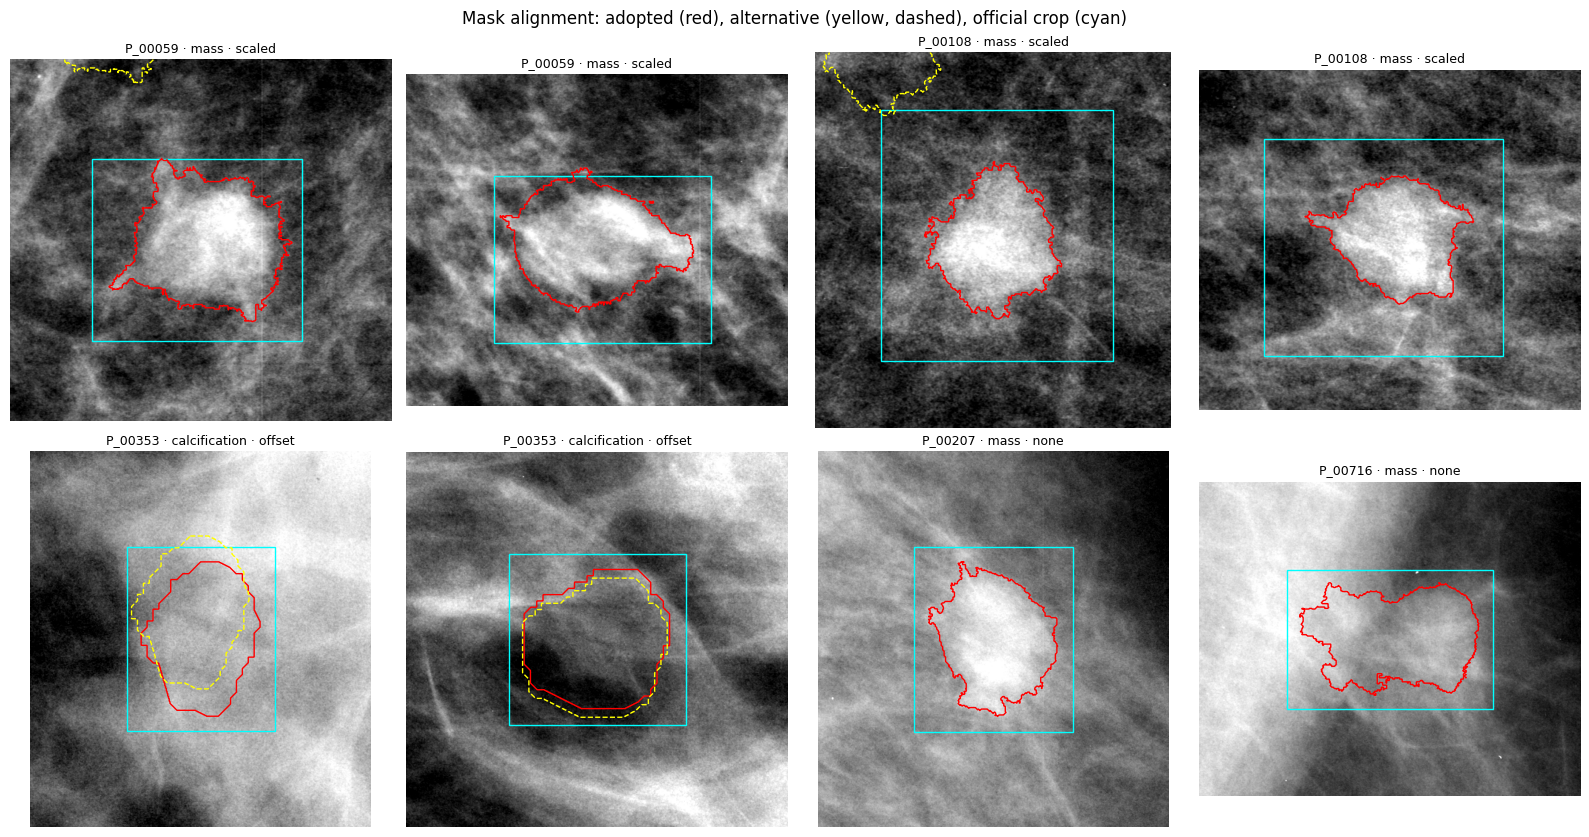

In [9]:
def show_alignment(ax, i, pad=150):
    row = df.loc[i]
    img = pydicom.dcmread(row.path_full_mammo).pixel_array
    raw = (pydicom.dcmread(row.path_roi_mask).pixel_array > 0).astype(np.uint8)
    m = align_mask(raw, img.shape, row.mismatch)
    alt = align_mask(raw, img.shape, ALT[row.mismatch]) if row.mismatch != "none" else None
    y0, y1, x0, x1 = bbox(m)
    Y0, Y1 = max(0, y0 - pad), min(img.shape[0], y1 + pad)
    X0, X1 = max(0, x0 - pad), min(img.shape[1], x1 + pad)
    v = img[Y0:Y1, X0:X1].astype(np.float32)
    lo, hi = np.percentile(v, [1, 99.5])
    ax.imshow(np.clip((v - lo) / (hi - lo), 0, 1), cmap="gray")
    ax.contour(m[Y0:Y1, X0:X1], levels=[0.5], colors="red", linewidths=1)
    if alt is not None and alt[Y0:Y1, X0:X1].any():
        ax.contour(alt[Y0:Y1, X0:X1], levels=[0.5], colors="yellow", linewidths=1, linestyles="--")
    if pd.notna(row.path_cropped):
        crop = pydicom.dcmread(row.path_cropped).pixel_array
        cy, cx, _ = locate(img, crop)
        ax.add_patch(plt.Rectangle((cx - X0, cy - Y0), crop.shape[1], crop.shape[0], fill=False, ec="cyan", lw=1))
    ax.set_title(f"{row.patient_id} · {row.finding_type} · {row.mismatch}", fontsize=9)
    ax.axis("off")


show = list(df.index[df.mismatch == "scaled"][:4]) + list(df.index[df.mismatch == "offset"]) + list(control_idx[:2])
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, i in zip(axes.ravel(), show):
    show_alignment(ax, i)
fig.suptitle("Mask alignment: adopted (red), alternative (yellow, dashed), official crop (cyan)")
plt.tight_layout()
plt.savefig(FIG_DIR / "M2_mask_alignment.png", dpi=150, bbox_inches="tight")
plt.show()

**f.** Consequence

- `offset` masks are anchored without scaling; the official crops confirm it exactly.
- `scaled` masks are resampled. The official crops cannot confirm it, but the contrast
  test does: resampled masks behave like the aligned controls, and the unscaled
  alternative is clearly worse.
- None of the 80 records has to be discarded, so no masses are lost (H-004 warned that
  dropping them would remove 78 masses).

#### **4° Mask cleaning**

**a.** The question

Each record annotates **one** lesion, so its mask should be a single connected region.
The audit of section 2 says otherwise for most masses: they carry small disconnected
islands, a few pixels each, left over from rasterising the outline.

Those islands are harmless for the intensity features, but not for the shape features.
PyRadiomics computes `Perimeter` over every component and `MaximumDiameter` as the
largest distance between any two points of the mask. A single stray pixel far from the
lesion would inflate the diameter, and H-003 found that size features are the most
discriminative ones for masses.

In [10]:
for ft, g in df.groupby("finding_type"):
    multi = g[g.n_components > 1]
    print(f"{ft}: {len(multi)} / {len(g)} masks with more than one component ({len(multi) / len(g):.1%})")
    if len(multi):
        print(f"    share of the area in the largest component: min {(multi.largest_component / multi.mask_area_raw).min():.4f}")
        print(f"    second-largest component: median {multi.second_component.median():.0f} px, "
              f"max {multi.second_component.max()} px")
        print(f"    masks with two components of >= 100 px: {((g.n_components > 1) & (g.second_component >= 100)).sum()}")

calcification: 0 / 1872 masks with more than one component (0.0%)
mass: 1464 / 1696 masks with more than one component (86.3%)
    share of the area in the largest component: min 0.9955
    second-largest component: median 2 px, max 64 px
    masks with two components of >= 100 px: 0


**b.** The rule

The lesion is the **largest connected component** (8-connectivity), and the rest is
discarded. The alternatives are worse:

- *Keep everything*: contaminates `Perimeter` and `MaximumDiameter`.
- *Morphological opening*: removes the islands but also erodes the real border, which is
  exactly where spiculation lives.
- *Area threshold*: needs an arbitrary cut-off, while the data show the largest component
  always holds more than 99.5 % of the area.

For every mask the discarded area and the distance from the farthest discarded pixel to
the lesion are recorded, which bounds how much the islands could have distorted the
shape features.

In [11]:
def prepare_mask(i):
    # Aligned, cleaned mask (uint8, 0/1) in the image space, plus cleaning diagnostics
    row = df.loc[i]
    raw = (pydicom.dcmread(row.path_roi_mask).pixel_array > 0).astype(np.uint8)
    m = align_mask(raw, (row.img_rows, row.img_cols), row.mismatch)
    n, lab, st, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n <= 2:
        return m, 0, 0.0
    k = 1 + int(np.argmax(st[1:, cv2.CC_STAT_AREA]))
    main = (lab == k).astype(np.uint8)
    rest = (lab > 0) & (lab != k)
    reach = cv2.distanceTransform(1 - main, cv2.DIST_L2, 5)[rest].max()
    return main, int(rest.sum()), float(reach)


def clean_record(i):
    main, removed, reach = prepare_mask(i)
    y0, y1, x0, x1 = bbox(main)
    return dict(i=i, mask_area=int(main.sum()), area_removed=removed, speck_reach_px=reach,
                bbox_h=y1 - y0, bbox_w=x1 - x0)


t0 = time.time()
with ThreadPoolExecutor(N_WORKERS) as ex:
    clean = pd.DataFrame(list(ex.map(clean_record, df.index))).set_index("i")
df = df.join(clean)
print(f"Cleaned {len(df)} masks in {time.time() - t0:.0f} s")
print()
touched = df[df.area_removed > 0]
print(f"Masks modified: {len(touched)}  ({len(touched) / len(df):.1%})")
print(f"Area removed: median {touched.area_removed.median():.0f} px, max {touched.area_removed.max()} px, "
      f"max share of the mask {(touched.area_removed / (touched.mask_area + touched.area_removed)).max():.2%}")
print("Distance from the farthest discarded pixel to the lesion (px):")
print(touched.speck_reach_px.describe(percentiles=[.5, .9, .99]).round(1).to_string())

Cleaned 3568 masks in 140 s

Masks modified: 1464  (41.0%)
Area removed: median 5 px, max 110 px, max share of the mask 0.45%
Distance from the farthest discarded pixel to the lesion (px):
count    1464.0
mean        3.9
std         1.3
min         2.0
50%         3.6
90%         5.2
99%         9.2
max        14.0


**c.** Consequence

The islands turn out to sit right next to the lesion: the farthest discarded pixel is
14 px away and the median about 4 px. Since a point at distance $d$ from the lesion can
lengthen `MaximumDiameter` by at most $d$, the effect on the diameter is bounded by a few
pixels, around 1 % of a typical mass of 300 px. `Perimeter`, which adds the border of
every component, is the feature most exposed.

Cleaning is still the right call, because it is what a single-lesion annotation means,
but its effect on the Module 3 features will be small. Knowing that in advance matters:
it rules out the islands as an explanation if the shape features behave unexpectedly.

#### **5° Crop and export**

**a.** What is written

For every record, three files in `Data/processed/m2/<finding_type>/`:

| File | Content | Used by |
|---|---|---|
| `<case_id>_image.nrrd` | Crop of the mammogram, **raw 16-bit intensities** | M3, radiomic path |
| `<case_id>_mask.nrrd` | Aligned, cleaned mask on the same grid, values 0/1 | M3 |
| `<case_id>_clahe.nrrd` | Same crop after CLAHE on the full mammogram, 8 bits | M3, comparison only (D-010) |

- The crop is the lesion bounding box plus `MARGIN` px, cut at the image border when the
  lesion touches it.
- Intensities are **not** normalised to $[0, 1]$. With `binCount=32` (D-008) the texture
  features are invariant to a linear change of intensity anyway, and a per-image min-max
  normalisation would make the first-order features depend on the brightest and darkest
  pixel of the whole mammogram, which has nothing to do with the lesion.
- CLAHE is applied to the **full** mammogram and then cropped, which is what the TT1
  design specified, so the variant measures the effect of that design. Section 5b
  explains why it runs on 8 bits.
- NRRD with spacing $(1, 1)$: `PixelSpacing` is absent from every DICOM (H-002), so every
  distance is in pixels. SimpleITK writes it and PyRadiomics reads it directly.

Each mammogram is read once, even when it holds several lesions.

**b.** The CLAHE variant: why on 8 bits

OpenCV's CLAHE accepts 8- and 16-bit images, and its `clipLimit` is expressed relative
to the height of a flat histogram, which depends on the number of bins. On 16 bits there
are 65,536 bins, and a mammogram tile occupies only a fraction of them. The clip then
removes most of the histogram and spreads it uniformly over the whole range, and an
equalisation built from a nearly uniform histogram is nearly the identity.

The check below compares three versions on 30 random lesions. Two numbers per version:
the correlation with the raw intensities inside the lesion (1 means an affine change,
which `binCount` binning ignores) and the gain in lesion contrast relative to the whole
mammogram. The third version isolates the effect of quantising to 8 bits.

In [12]:
def to_uint8(img):
    lo, hi = float(img.min()), float(img.max())
    return np.round((img.astype(np.float64) - lo) / (hi - lo) * 255).astype(np.uint8)


def clahe_variants(img):
    u8 = to_uint8(img)
    return {
        "CLAHE on 16 bits, clip 2": cv2.createCLAHE(CLAHE_CLIP, CLAHE_TILES).apply(img),
        "CLAHE on 8 bits, clip 2": cv2.createCLAHE(CLAHE_CLIP, CLAHE_TILES).apply(u8),
        "8 bits, no CLAHE": u8,
    }


rank = lambda v: np.argsort(np.argsort(v))
rows = []
for i in df.sample(30, random_state=SEED).index:
    row = df.loc[i]
    img = pydicom.dcmread(row.path_full_mammo).pixel_array
    mask, _, _ = prepare_mask(i)
    y0, y1, x0, x1 = bbox(mask)
    x = img[y0:y1, x0:x1][mask[y0:y1, x0:x1] > 0].astype(float)
    for name, v in clahe_variants(img).items():
        y = v[y0:y1, x0:x1][mask[y0:y1, x0:x1] > 0].astype(float)
        rows.append(dict(version=name, pearson=np.corrcoef(x, y)[0, 1],
                         spearman=np.corrcoef(rank(x), rank(y))[0, 1],
                         contrast_gain=(y.std() / v.std()) / (x.std() / img.std())))
clahe_check = pd.DataFrame(rows).groupby("version").agg(
    pearson_median=("pearson", "median"), pearson_min=("pearson", "min"),
    spearman_median=("spearman", "median"),
    contrast_gain_median=("contrast_gain", "median"), contrast_gain_max=("contrast_gain", "max"))
clahe_check.to_csv(RESULTS_DIR / "2_clahe_configuracion.csv")
print(clahe_check.round(3).to_string())

                          pearson_median  pearson_min  spearman_median  contrast_gain_median  contrast_gain_max
version                                                                                                        
8 bits, no CLAHE                   1.000        0.988            0.999                 1.000              1.026
CLAHE on 16 bits, clip 2           1.000        0.987            1.000                 1.023              1.453
CLAHE on 8 bits, clip 2            0.972        0.617            0.975                 1.614              2.641


On 16 bits CLAHE is indistinguishable from doing nothing, so a comparison built on it
would conclude that CLAHE has no effect, and that conclusion would be an artefact of the
configuration. On 8 bits it is a genuine local, non-linear transformation, and
quantising to 8 bits on its own changes nothing measurable. The variant is therefore
exported on 8 bits: normalise the mammogram to its own range, convert to `uint8`, apply
CLAHE. That is also the natural reading of the TT1 design, which normalised first
(RF-04) and then applied OpenCV's CLAHE (RF-05).

**c.** Export

In [13]:
def write_nrrd(arr, path):
    im = sitk.GetImageFromArray(arr)
    im.SetSpacing((1.0, 1.0))  # no PixelSpacing in the DICOM (H-002): pixel units
    sitk.WriteImage(im, str(path), useCompression=True)


def export_mammogram(item):
    path_full, idxs = item
    img = pydicom.dcmread(path_full).pixel_array
    eq = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILES).apply(to_uint8(img))
    recs = []
    for i in idxs:
        row = df.loc[i]
        mask, _, _ = prepare_mask(i)
        y0, y1, x0, x1 = bbox(mask)
        Y0, Y1 = max(0, y0 - MARGIN), min(img.shape[0], y1 + MARGIN)
        X0, X1 = max(0, x0 - MARGIN), min(img.shape[1], x1 + MARGIN)
        base = OUT_DIR / row.finding_type / row.case_id
        paths = {k: base.with_name(f"{row.case_id}_{k}.nrrd") for k in ("image", "mask", "clahe")}
        write_nrrd(img[Y0:Y1, X0:X1], paths["image"])
        write_nrrd(mask[Y0:Y1, X0:X1], paths["mask"])
        write_nrrd(eq[Y0:Y1, X0:X1], paths["clahe"])
        recs.append(dict(i=i, crop_y0=Y0, crop_x0=X0, crop_h=Y1 - Y0, crop_w=X1 - X0,
                         margin_clipped=(Y0 > y0 - MARGIN) or (Y1 < y1 + MARGIN) or (X0 > x0 - MARGIN) or (X1 < x1 + MARGIN),
                         **{f"path_{k}": str(p.relative_to(DATA_DIR)) for k, p in paths.items()}))
    return recs


groups = list(df.groupby("path_full_mammo").groups.items())
t0 = time.time()
with ThreadPoolExecutor(N_WORKERS) as ex:
    exported = [r for recs in ex.map(export_mammogram, groups) for r in recs]
exp = pd.DataFrame(exported).set_index("i")
df = df.join(exp)
elapsed = time.time() - t0

size_gb = sum(f.stat().st_size for f in OUT_DIR.rglob("*.nrrd")) / 1e9
print(f"Exported {len(exp)} lesions from {len(groups)} mammograms in {elapsed / 60:.1f} min "
      f"({elapsed / len(exp):.2f} s per lesion), {size_gb:.2f} GB on disk")
print(f"Crops cut at the image border: {df.margin_clipped.sum()}")
print()
print("Lesion bounding box (px), by finding type:")
print(df.groupby("finding_type")[["bbox_h", "bbox_w"]].describe(percentiles=[.5]).T.round(0).to_string())

Exported 3568 lesions from 3103 mammograms in 5.8 min (0.10 s per lesion), 2.17 GB on disk
Crops cut at the image border: 187

Lesion bounding box (px), by finding type:
finding_type  calcification    mass
bbox_h count         1872.0  1696.0
       mean           422.0   328.0
       std            445.0   136.0
       min             33.0    86.0
       50%            273.0   302.0
       max           3801.0  1329.0
bbox_w count         1872.0  1696.0
       mean           432.0   331.0
       std            421.0   136.0
       min             33.0    55.0
       50%            289.0   304.0
       max           2873.0  1365.0


**d.** Save the index

`Data/processed/m2_index.parquet` is the hand-off to Module 3: one row per lesion with its
labels, its three file paths (relative to `Data/`) and every diagnostic of this notebook.
A copy without file paths goes to `Code/results/` so the audit is versioned.

In [14]:
keep = ["case_id", "patient_id", "finding_type", "split", "label", "pathology",
        "left or right breast", "image view", "abnormality id",
        "img_rows", "img_cols", "mask_rows", "mask_cols", "mismatch",
        "n_components", "mask_area_raw", "mask_area", "area_removed", "speck_reach_px",
        "bbox_h", "bbox_w", "crop_y0", "crop_x0", "crop_h", "crop_w", "margin_clipped",
        "ncc", "gain", "rule_ok", "rule_ok_alternative", "near_border", "crop_check"]
index = df[keep + ["path_image", "path_mask", "path_clahe"]].copy()
index.to_parquet(DATA_DIR / "processed" / "m2_index.parquet", index=False)
index[keep].to_csv(RESULTS_DIR / "2_preprocesamiento_qa.csv", index=False)

by_type = df.groupby("finding_type").agg(
    lesions=("case_id", "size"),
    misaligned_scaled=("mismatch", lambda s: (s == "scaled").sum()),
    misaligned_offset=("mismatch", lambda s: (s == "offset").sum()),
    masks_cleaned=("area_removed", lambda s: (s > 0).sum()),
    official_crop_rule_ok=("crop_check", lambda s: (s == "ok").sum()),
    official_crop_border=("crop_check", lambda s: (s == "border").sum()),
    official_crop_discordant=("crop_check", lambda s: (s == "discordant").sum()),
    without_official_crop=("crop_check", lambda s: (s == "no_official_crop").sum()),
    median_bbox_h=("bbox_h", "median"), median_bbox_w=("bbox_w", "median"),
    border_clipped=("margin_clipped", "sum"))
by_type.to_csv(RESULTS_DIR / "2_preprocesamiento_resumen.csv")
print(by_type.T.to_string())

finding_type              calcification    mass
lesions                          1872.0  1696.0
misaligned_scaled                   0.0    78.0
misaligned_offset                   2.0     0.0
masks_cleaned                       0.0  1464.0
official_crop_rule_ok            1663.0  1543.0
official_crop_border               95.0    67.0
official_crop_discordant            0.0     7.0
without_official_crop             114.0     1.0
median_bbox_h                     273.0   302.0
median_bbox_w                     289.0   304.5
border_clipped                    120.0    67.0


#### **6° Checks on the exported files**

**a.** Round trip

A sample of files is read back to confirm geometry, types and values, and that the mask
on disk is the cleaned mask.

In [15]:
rng = np.random.default_rng(SEED)
sample = rng.choice(df.index, 200, replace=False)
problems = []
for i in sample:
    row = df.loc[i]
    im = sitk.ReadImage(str(DATA_DIR / row.path_image))
    mk = sitk.ReadImage(str(DATA_DIR / row.path_mask))
    a, m = sitk.GetArrayFromImage(im), sitk.GetArrayFromImage(mk)
    ok = (a.shape == m.shape == (row.crop_h, row.crop_w) and a.dtype == np.uint16
          and set(np.unique(m)) == {0, 1} and int(m.sum()) == row.mask_area
          and im.GetSpacing() == (1.0, 1.0))
    if not ok:
        problems.append(row.case_id)
print(f"Round trip on {len(sample)} random lesions: {len(sample) - len(problems)} correct, {len(problems)} with problems")

Round trip on 200 random lesions: 200 correct, 0 with problems


**b.** PyRadiomics smoke test

Not the Module 3 extraction, only a check that the files are accepted as they are: two
lesions per finding type, with the settings fixed for Module 3 (`binCount=32`, D-008).

In [16]:
from radiomics import featureextractor
import logging
logging.getLogger("radiomics").setLevel(logging.ERROR)

extractor = featureextractor.RadiomicsFeatureExtractor(binCount=32, force2D=True, label=1)
extractor.disableAllFeatures()
extractor.enableFeatureClassByName("shape2D")
extractor.enableFeatureClassByName("firstorder")

smoke = []
for ft in ("mass", "calcification"):
    for i in df[df.finding_type == ft].sample(2, random_state=SEED).index:
        row = df.loc[i]
        t0 = time.time()
        feats = extractor.execute(str(DATA_DIR / row.path_image), str(DATA_DIR / row.path_mask))
        smoke.append(dict(case_id=row.case_id, n_features=sum(k.startswith("original_") for k in feats),
                          PixelSurface=float(feats["original_shape2D_PixelSurface"]),
                          mask_area=row.mask_area,
                          MaximumDiameter=float(feats["original_shape2D_MaximumDiameter"]),
                          seconds=round(time.time() - t0, 2)))
print(pd.DataFrame(smoke).to_string(index=False))

                          case_id  n_features  PixelSurface  mask_area  MaximumDiameter  seconds
 Mass-Training_P_00889_LEFT_MLO_1          27       64629.0      64629       358.665582     0.06
Mass-Training_P_00148_RIGHT_MLO_1          27       55730.0      55730       303.659349     0.03
     Calc-Test_P_01022_LEFT_MLO_1          27       12373.0      12373       156.310588     0.01
 Calc-Training_P_01570_RIGHT_CC_1          27      216901.0     216901       595.813729     0.07

`PixelSurface` has to equal the mask area of the index: it is the same count of pixels
computed by two independent pieces of software.

#### **7° Visual examples**

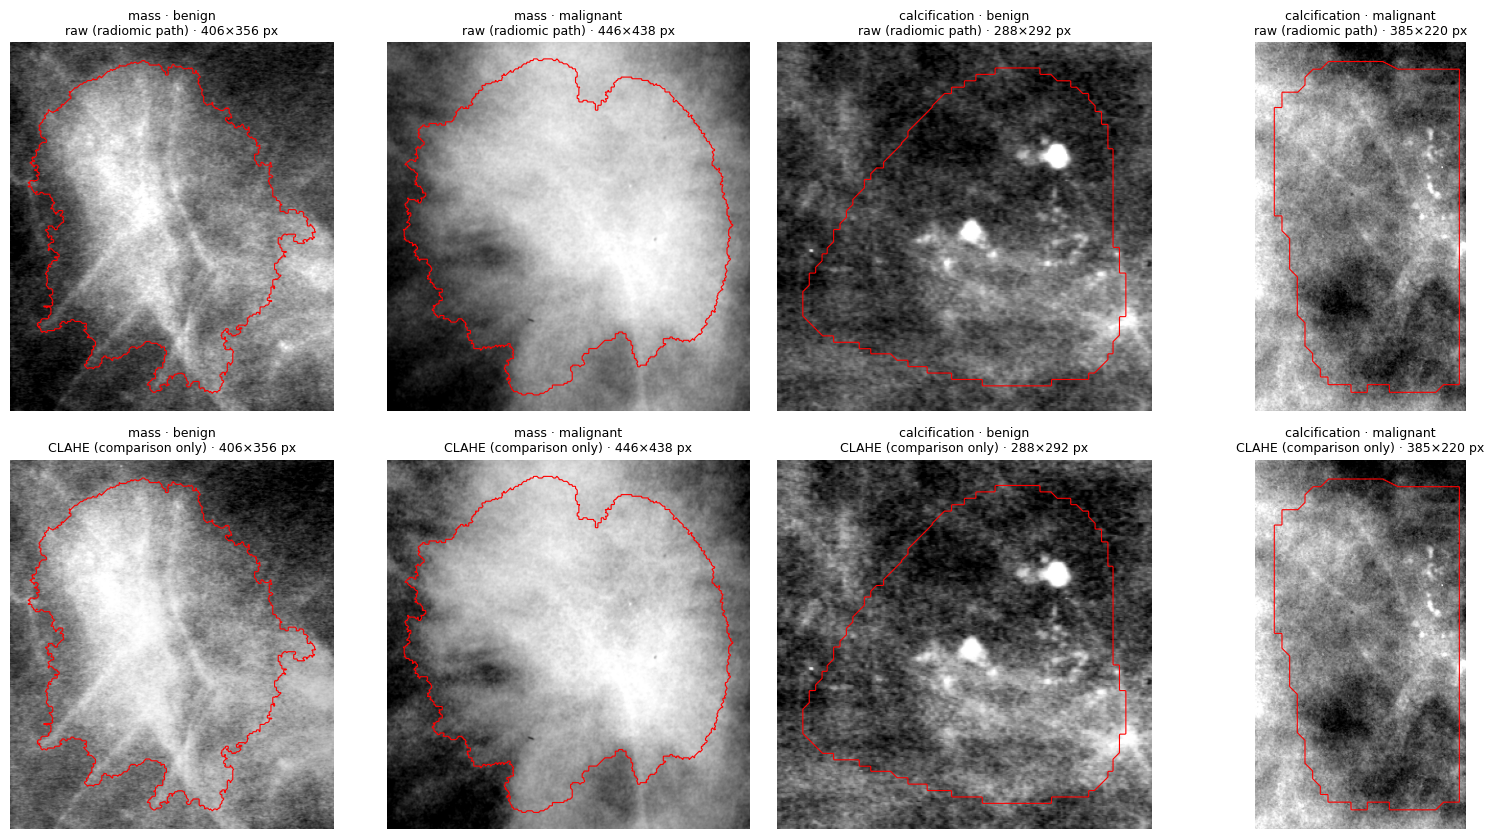

In [17]:
def show_case(ax_raw, ax_eq, i):
    row = df.loc[i]
    a = sitk.GetArrayFromImage(sitk.ReadImage(str(DATA_DIR / row.path_image))).astype(np.float32)
    e = sitk.GetArrayFromImage(sitk.ReadImage(str(DATA_DIR / row.path_clahe))).astype(np.float32)
    m = sitk.GetArrayFromImage(sitk.ReadImage(str(DATA_DIR / row.path_mask)))
    for ax, v, name in ((ax_raw, a, "raw (radiomic path)"), (ax_eq, e, "CLAHE (comparison only)")):
        lo, hi = np.percentile(v, [1, 99.5])
        ax.imshow(np.clip((v - lo) / (hi - lo), 0, 1), cmap="gray")
        ax.contour(m, levels=[0.5], colors="red", linewidths=0.8)
        ax.set_title(f"{row.finding_type} · {'malignant' if row.label else 'benign'}\n{name} · {row.crop_h}×{row.crop_w} px", fontsize=9)
        ax.axis("off")


picks = [df[(df.finding_type == ft) & (df.label == lb) & (df.split == "train")].sample(1, random_state=SEED).index[0]
         for ft in ("mass", "calcification") for lb in (0, 1)]
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for j, i in enumerate(picks):
    show_case(axes[0, j], axes[1, j], i)
plt.tight_layout()
plt.savefig(FIG_DIR / "M2_preprocessing_examples.png", dpi=150, bbox_inches="tight")
plt.show()

#### **8° Summary**

In [18]:
s = by_type
v = df[df.ncc.notna()]
print("=" * 70)
print("MODULE 2 - PREPROCESSING - SUMMARY")
print("=" * 70)
print(f"  Lesions exported           : {len(df)}  ({s.loc['mass', 'lesions']} masses, {s.loc['calcification', 'lesions']} calcifications)")
print(f"  Resolution                 : original, no resize (D-009); crop = bbox + {MARGIN} px")
print(f"  Intensities                : raw 16-bit; CLAHE (8-bit) only in the comparison variant (D-010)")
g = clahe_check["contrast_gain_median"]
print(f"     CLAHE lesion-contrast gain: {g['CLAHE on 8 bits, clip 2']:.2f} on 8 bits vs {g['CLAHE on 16 bits, clip 2']:.2f} on 16 bits")
print()
print(f"  1. Misaligned masks        : {(df.mismatch == 'scaled').sum()} scaled by 0.870, {(df.mismatch == 'offset').sum()} offset")
cc = df.crop_check.value_counts()
print(f"     official-crop rule holds : {cc.get('ok', 0)} / {cc.get('ok', 0) + cc.get('discordant', 0)} checkable records "
      f"({cc.get('border', 0)} at the image border, {cc.get('discordant', 0)} discordant)")
print(f"     offset masks, rule holds with top-left anchor : {int(v[v.mismatch == 'offset'].rule_ok.sum())} / {(v.mismatch == 'offset').sum()}")
print(f"     scaled masks: contrast test, median distance to optimum "
      f"{summary.loc['scaled: resampled', 'median_dist_to_optimum_px']:.1f} px "
      f"(aligned controls {summary.loc['aligned controls', 'median_dist_to_optimum_px']:.1f} px)")
print()
print(f"  2. Masks cleaned           : {(df.area_removed > 0).sum()} (largest component kept)")
print(f"     farthest discarded pixel: {df.speck_reach_px.max():.0f} px from its lesion")
print()
print(f"  3. Official crops          : intensity gain {v.gain.min():.2f}-{v.gain.max():.2f}, not used for features")
print(f"  4. Round trip / PyRadiomics: {len(sample) - len(problems)}/{len(sample)} files correct, smoke test passed")
print("=" * 70)

MODULE 2 - PREPROCESSING - SUMMARY
  Lesions exported           : 3568  (1696 masses, 1872 calcifications)
  Resolution                 : original, no resize (D-009); crop = bbox + 20 px
  Intensities                : raw 16-bit; CLAHE (8-bit) only in the comparison variant (D-010)
     CLAHE lesion-contrast gain: 1.61 on 8 bits vs 1.02 on 16 bits

  1. Misaligned masks        : 78 scaled by 0.870, 2 offset
     official-crop rule holds : 3206 / 3213 checkable records (162 at the image border, 7 discordant)
     offset masks, rule holds with top-left anchor : 2 / 2
     scaled masks: contrast test, median distance to optimum 1.4 px (aligned controls 4.3 px)

  2. Masks cleaned           : 1464 (largest component kept)
     farthest discarded pixel: 14 px from its lesion

  3. Official crops          : intensity gain 1.00-5.31, not used for features
  4. Round trip / PyRadiomics: 200/200 files correct, smoke test passed
